In [10]:
import random
import os
import numpy as np
import pandas as pd
from eruption_forecast.plots.forecast_plots import plot_forecast_from_file
import matplotlib
from matplotlib import pyplot as plt

from eruption_forecast.utils.formatting import pdf_metadata

In [11]:
df = pd.read_csv(r"D:\Projects\eruption-forecast\output\VG.LEKR.00.EHZ\predictions\result_all_model_predictions_2022-11-01_2022-12-07.csv", parse_dates=True, index_col=0)
df.head(5)

,LiteRandomForestClassifier_probability,LiteRandomForestClassifier_uncertainty,LiteRandomForestClassifier_prediction,LiteRandomForestClassifier_confidence,RandomForestClassifier_probability,RandomForestClassifier_uncertainty,RandomForestClassifier_prediction,RandomForestClassifier_confidence,consensus_probability,consensus_uncertainty,consensus_prediction,consensus_confidence
datetime,,,,,,,,,,,,
2022-11-01 00:00:00,0.062750,0.057483,0.0,0.0,0.076404,0.060778,0.0,0.0,0.069577,0.006827,0.0,0.0
2022-11-01 00:10:00,0.063749,0.056498,0.0,0.0,0.080415,0.057364,0.0,0.0,0.072082,0.008333,0.0,0.0
2022-11-01 00:20:00,0.072129,0.062295,0.0,0.0,0.086472,0.063087,0.0,0.0,0.079300,0.007171,0.0,0.0
2022-11-01 00:30:00,0.061854,0.049490,0.0,0.0,0.072566,0.048222,0.0,0.0,0.067210,0.005356,0.0,0.0
2022-11-01 00:40:00,0.062670,0.052991,0.0,0.0,0.069544,0.051819,0.0,0.0,0.066107,0.003437,0.0,0.0


In [12]:
ERUPTION_WINDOWS = [
    ("2022-11-06 12:00:00", "2022-11-10 00:00:00"),
    ("2022-11-06 10:00:00", "2022-11-07 20:00:00"),
    ("2022-12-01 10:00:00", "2022-12-01 22:00:00"),
    ("2022-12-01 18:00:00", "2022-12-03 16:00:00"),
    ("2022-12-02 18:00:00", "2022-12-03 04:00:00"),
    ("2022-12-01 18:00:00", "2022-12-04 00:00:00"),
    ("2022-12-04 04:00:00", "2022-12-04 06:00:00"),
    ("2022-12-04 08:00:00", "2022-12-04 12:00:00"),
    ("2022-12-04 06:00:00", "2022-12-04 10:00:00"),
    ("2022-12-01 10:00:00", "2022-12-02 16:00:00"),
    ("2022-12-04 00:00:00", "2022-12-05 20:00:00"),
    ("2022-12-05 18:00:00", "2022-12-06 07:00:00"),
    ("2022-12-05 20:00:00", "2022-12-06 08:00:00"),
]

In [13]:
prob_cols = [
    col
    for col in df.columns
    if (col.endswith("_probability") and not col.startswith("consensus"))
]

pred_cols = [
    col
    for col in df.columns
    if (col.endswith("_prediction") and not col.startswith("consensus"))
]

cols = prob_cols + pred_cols
cols

['LiteRandomForestClassifier_probability',
 'RandomForestClassifier_probability',
 'LiteRandomForestClassifier_prediction',
 'RandomForestClassifier_prediction']

In [14]:
def apply_randomness(row):
    randomness_ = random.uniform(0.08, 0.06)
    for col in pred_cols:
        model_name = col.split("_")[0]
        row[f"{model_name}_probability"] = row[f"{model_name}_probability"] - (randomness_ * random.uniform(2, 4))
        row[col] = row[f"{model_name}_probability"] + (np.sin(randomness_) * random.uniform(1, 3))

        if row[col] >= 0.9:
            row[f"{model_name}_probability"] = row[f"{model_name}_probability"] - (randomness_ * random.uniform(1, 3))
            row[col] = row[f"{model_name}_probability"] - (np.sin(randomness_))

    return row

In [15]:
for eruptions in ERUPTION_WINDOWS:
    mask = (df.index >= eruptions[0]) & (df.index <= eruptions[-1])
    df.loc[mask, cols] = df.loc[mask, cols].apply(lambda row: apply_randomness(row), axis=1)

In [16]:
df.to_csv("output/result_all_model_predictions_2022-11-01_2022-12-07.csv", index=True)

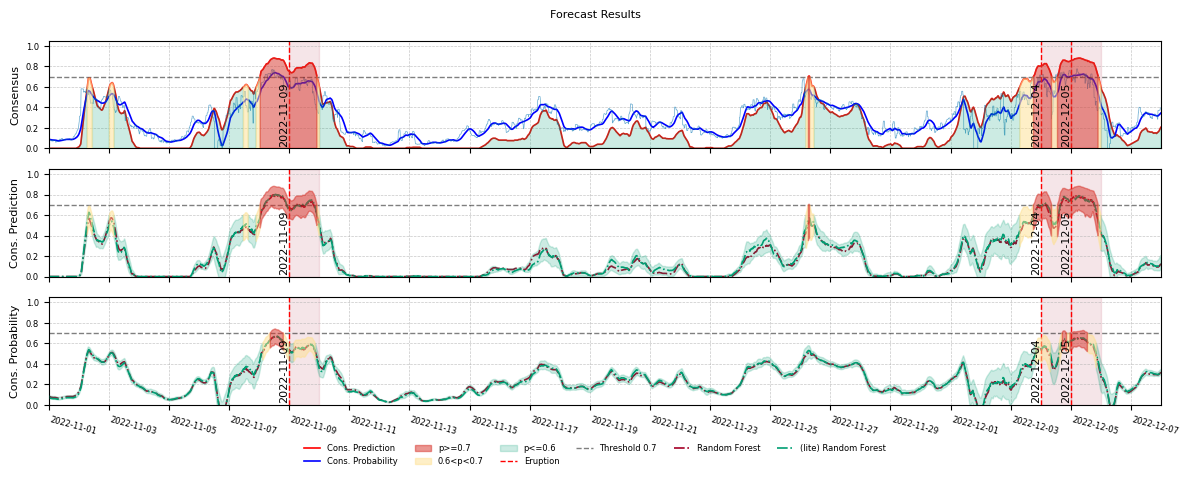

In [17]:
%matplotlib inline
fig = plot_forecast_from_file(
    consensus_file=r"D:\Projects\eruption-forecast-examples\output\result_all_model_predictions_2022-11-01_2022-12-07.csv",
    eruption_dates=["2022-11-09","2022-12-04","2022-12-05"]
)

path = os.path.join("output/result_all_model_predictions_2022-11-01_2022-12-07.pdf")
with matplotlib.rc_context({"pdf.fonttype": 42}):
    fig.savefig(
        path,
        bbox_inches="tight",
        facecolor="white",
        edgecolor=None,
        metadata=pdf_metadata(f"Eruption Forecast: Semeru"),
    )

plt.show()